# 第17章：Tensor Core 深入 -- tl.dot 的秘密

## 前置知识
- 第09章：分块矩阵乘法基础
- 第12章：共享内存与 bank conflict
- 第16章：混合精度策略
- 了解 GPU warp (32线程) 的概念

## 学习目标
- 理解 **Tensor Core** 是什么 (硬件矩阵乘法单元)
- 理解 `tl.dot` 如何映射到 `mma.sync` PTX 指令
- 理解 CUDA WMMA API 和 MMA PTX 的区别
- 理解为什么 Block Size 必须是 16 的倍数
- 理解 **nd vs nz** 共享内存布局与 ldmatrix/mma 的关系
- 对比 CUDA 手写 Tensor Core 代码 vs Triton 的简洁性

## 对应 CUDA 代码
- `src/wmma/00wmma_naive.cu` — WMMA API (高层封装, 0.2952ms, Blackwell)
- `src/mma/00mma_naive.cu` — MMA PTX 内联汇编 (0.3138ms, naive, Blackwell)
- `src/mma/02mma_smem.cu` — MMA + 共享内存 (nd 布局, 0.2155ms)
- `src/mma/03mma_ldmatrix.cu` — MMA + ldmatrix (nz 布局, 0.2149ms)
- `src/mma/04mma_pipline.cu` — MMA PTX + 流水线 (0.1844ms, 优化版, Blackwell)

In [1]:
import torch
import triton
import triton.language as tl

## 17.1 Tensor Core 是什么？

### 硬件概述

Tensor Core 是 NVIDIA GPU 中的专用**矩阵乘法硬件单元**，
与传统的 CUDA Core (标量 FMA) 完全不同：

```
CUDA Core (标量运算):              Tensor Core (矩阵运算):
  一次计算: a * b + c              一次计算: D = A * B + C
  操作数: 标量                      操作数: 矩阵片段
  FP32: 1 FLOP/cycle/core         FP16: 几十~几百 FLOP/cycle/core
  
  ┌─┐   ┌─┐   ┌─┐                ┌─────┐   ┌─────┐   ┌─────┐
  │a│ * │b│ + │c│ = d             │  A  │ * │  B  │ + │  C  │ = D
  └─┘   └─┘   └─┘                │m×k  │   │k×n  │   │m×n  │   m×n
                                  └─────┘   └─────┘   └─────┘
```

### Tensor Core 的矩阵大小

不同架构支持的原子矩阵乘大小：

```
架构       指令                  矩阵大小 (M x N x K)     精度
────────────────────────────────────────────────────────────────
Volta      WMMA                  16 x 16 x 16             FP16→FP16/FP32
Turing     WMMA/MMA              16 x 16 x 16 / 16x8x8   FP16→FP16/FP32
Ampere     MMA                   16 x 8 x 8               FP16/BF16/TF32
                                 16 x 8 x 16              FP16/BF16
Hopper     WGMMA                 64 x N x 16              各种精度
```

### Warp 级别操作

Tensor Core 是 **warp 级别** 的操作 —— 一个 warp (32 线程) 协作完成一次矩阵乘：

```
WMMA (16x16x16):
                                    
  A (16x16)     B (16x16)     C (16x16)
  ┌─────────┐   ┌─────────┐   ┌─────────┐
  │ Thread 0│   │ Thread 0│   │ Thread 0│
  │ Thread 1│   │ Thread 1│   │ Thread 1│
  │   ...   │ @ │   ...   │ = │   ...   │
  │Thread 31│   │Thread 31│   │Thread 31│
  └─────────┘   └─────────┘   └─────────┘
  
  每个线程持有矩阵的几个元素 (fragment)
  32 个线程的 fragment 合在一起构成完整矩阵
  硬件一条指令完成整个矩阵乘!
```

## 17.2 CUDA 的三种 Tensor Core 编程方式

### 方式 1: WMMA API (高层封装)

```cpp
// 来自 wmma_naive.cu
#include <mma.h>
using namespace nvcuda::wmma;

// 1. 声明 fragment (矩阵片段)
fragment<matrix_a, 16, 16, 16, half, row_major> a_frag;
fragment<matrix_b, 16, 16, 16, half, row_major> b_frag;
fragment<accumulator, 16, 16, 16, half> c_frag;

// 2. 初始化累加器
fill_fragment(c_frag, half(0.0f));

// 3. 加载 + 计算
for (int k = 0; k < K; k += 16) {
    load_matrix_sync(a_frag, A_ptr + offset, ldA);
    load_matrix_sync(b_frag, B_ptr + offset, ldB);
    mma_sync(c_frag, a_frag, b_frag, c_frag);  // D = A * B + C
}

// 4. 存储
store_matrix_sync(C_ptr + offset, c_frag, ldC, mem_row_major);
```

**特点**：相对简单, 但性能不如手写 MMA, 灵活性有限。

### 方式 2: MMA PTX 内联汇编 (底层控制)

```cpp
// 来自 mma_naive.cu  
// 寄存器声明
uint32_t regD[2] = {0, 0};  // 输出 fragment

// PTX 内联汇编: mma.sync.aligned.m16n8k8
asm volatile(
    "mma.sync.aligned.m16n8k8.row.col.f16.f16.f16.f16 "
    "{%0, %1}, "         // D: 2个 u32 寄存器
    "{%2, %3}, "         // A: 2个 u32 寄存器
    "{%4}, "             // B: 1个 u32 寄存器
    "{%5, %6}; "         // C: 2个 u32 寄存器 (累加器)
    :"=r"(regD[0]), "=r"(regD[1])
    :"r"(*(uint32_t*)(A_ptr + thread_offset_a)),
     "r"(*(uint32_t*)(A_ptr + thread_offset_a + 8*K)),
     "r"(*(uint32_t*)(B_ptr + thread_offset_b)),
     "r"(regD[0]), "r"(regD[1])
);
```

**特点**：最大灵活性, 最高性能潜力, 但代码极其复杂。

### 方式 3: Triton tl.dot (自动映射)

```python
# 整个 Tensor Core 调用, 1 行 Python!
acc = tl.dot(a_tile, b_tile, acc=acc)
```

**特点**：编译器自动映射到最优的 MMA 指令, 开发效率极高。

## 17.3 tl.dot 如何映射到 mma.sync

### 编译器的工作

当 Triton 编译器看到 `tl.dot(a, b, acc=acc)` (假设 a 是 128x32, b 是 32x128) 时：

```
Step 1: 确定可用的 MMA 指令
  GPU = Ampere → mma.sync.aligned.m16n8k16.row.col.f16.f16.f16.f16
  原子操作大小: (16, 8, 16)

Step 2: 将大矩阵分解为 MMA 操作
  a (128x32) @ b (32x128) 需要:
  M方向: 128/16 = 8 个 MMA tiles
  N方向: 128/8  = 16 个 MMA tiles
  K方向: 32/16  = 2 步 K 迭代
  总计: 8 * 16 * 2 = 256 个 mma.sync 指令

Step 3: 将 MMA 操作分配给 warp
  每个 warp 处理若干 MMA tile
  warp 内的 32 个线程协作完成每个 MMA

Step 4: 安排数据搬运
  使用 ldmatrix 从 shared memory 加载到 MMA 寄存器
  确保数据对齐和布局正确
```

### 数据在线程间的分布

```
mma.sync.m16n8k8 的线程分布:

A 矩阵 (16x8, row-major):          B 矩阵 (8x8, col-major):
行: 0-7   → Thread 0-3 的 reg A    行: 0-7  → Thread 0-3 的 reg B
行: 8-15  → Thread 0-3 的 reg A'   (Lane 0: B[0:2], Lane 1: B[2:4]...)

每个线程持有:
  A: 2个 u32 寄存器 (= 4个 FP16 元素)
  B: 1个 u32 寄存器 (= 2个 FP16 元素)
  D: 2个 u32 寄存器 (= 4个 FP16 元素)

线程到矩阵元素的映射 (mma.m16n8k8):
  Thread(lane_id) 持有的元素:
  D 矩阵行: lane_id / 4         (行 0-7)
  D 矩阵列: (lane_id % 4) * 2   (列 0,2,4,6)
  regD[0]: D[row, col] 和 D[row, col+1]
  regD[1]: D[row+8, col] 和 D[row+8, col+1]
```

**Triton 对开发者隐藏了所有这些细节！**

## 17.4 Block Size 要求

### 为什么必须是 16 的倍数？

```
Tensor Core 的原子操作是 16xNxK 的矩阵乘:
  WMMA: 16x16x16
  MMA:  16x8x8 或 16x8x16

因此:
  BLOCK_M 必须是 16 的倍数 (M 方向按 16 划分)
  BLOCK_N 必须是 16 的倍数 (最好是 8 的倍数, 对 mma.m16n8k8)
  BLOCK_K 必须是 16 的倍数 (K 方向按 16 或 8 划分)
```

### 不满足要求时会怎样？

```python
# BLOCK_M=48 → 48 / 16 = 3 → OK (是16的倍数? 48=16*3, OK!)
# BLOCK_M=50 → 不是 16 的倍数 → Triton 编译器报错或退化到非 TC 路径
# BLOCK_K=24 → 不是 16 的倍数 → 可能报错
```

### 常见的有效 Block Size 组合

```
BLOCK_M  BLOCK_N  BLOCK_K  | 说明
──────────────────────────────────────
  16       16       16     | 最小有效 TC 配置
  32       32       16     | 小型 kernel
  64       64       32     | 中等
  128      128      32     | 常用最佳配置
  128      256      32     | 高算术强度
  256      128      32     | 高算术强度
  256      256      64     | 大配置 (需要大量 smem)
```

In [2]:
# ========== Tensor Core GEMM kernel ==========
@triton.jit
def matmul_tc_kernel(
    a_ptr, b_ptr, c_ptr,
    M, N, K,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):
    """
    标准 GEMM kernel, 使用 Tensor Core (通过 tl.dot)。
    
    一行 tl.dot 等价于 CUDA 中:
    - WMMA: ~15 行 (fragment 声明 + load + mma_sync + store)
    - MMA PTX: ~30 行 (寄存器声明 + asm + 手动存储)
    - MMA + ldmatrix: ~50 行 (加上 smem 布局优化)
    """
    pid = tl.program_id(0)
    grid_m = tl.cdiv(M, BLOCK_M)
    grid_n = tl.cdiv(N, BLOCK_N)
    group_id = pid // (GROUP_SIZE_M * grid_n)
    first_pid_m = group_id * GROUP_SIZE_M
    group_size_m = min(grid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + ((pid % (GROUP_SIZE_M * grid_n)) % group_size_m)
    pid_n = (pid % (GROUP_SIZE_M * grid_n)) // group_size_m
    
    a_block_ptr = tl.make_block_ptr(
        base=a_ptr, shape=(M, K), strides=(stride_am, stride_ak),
        offsets=(pid_m * BLOCK_M, 0), block_shape=(BLOCK_M, BLOCK_K), order=(1, 0),
    )
    b_block_ptr = tl.make_block_ptr(
        base=b_ptr, shape=(K, N), strides=(stride_bk, stride_bn),
        offsets=(0, pid_n * BLOCK_N), block_shape=(BLOCK_K, BLOCK_N), order=(1, 0),
    )
    
    # FP32 累加器
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    
    for k in range(0, K, BLOCK_K):
        a_tile = tl.load(a_block_ptr, boundary_check=(0, 1))
        b_tile = tl.load(b_block_ptr, boundary_check=(0, 1))
        # 这一行在编译后变成:
        # - ldmatrix 指令 (从 smem 加载到 MMA 寄存器)
        # - mma.sync.aligned 指令 (Tensor Core 矩阵乘)
        # - 可能的多轮 ldmatrix + mma (取决于 BLOCK_M/N/K vs MMA 原子大小)
        acc = tl.dot(a_tile, b_tile, acc=acc)
        a_block_ptr = tl.advance(a_block_ptr, (0, BLOCK_K))
        b_block_ptr = tl.advance(b_block_ptr, (BLOCK_K, 0))
    
    c_block_ptr = tl.make_block_ptr(
        base=c_ptr, shape=(M, N), strides=(stride_cm, stride_cn),
        offsets=(pid_m * BLOCK_M, pid_n * BLOCK_N),
        block_shape=(BLOCK_M, BLOCK_N), order=(1, 0),
    )
    tl.store(c_block_ptr, acc.to(tl.float16), boundary_check=(0, 1))


def matmul_tc(a, b, BLOCK_M=128, BLOCK_N=128, BLOCK_K=32, GROUP_SIZE_M=8):
    M, K = a.shape
    K2, N = b.shape
    assert K == K2
    c = torch.empty((M, N), device=a.device, dtype=a.dtype)
    grid = (triton.cdiv(M, BLOCK_M) * triton.cdiv(N, BLOCK_N),)
    matmul_tc_kernel[grid](
        a, b, c, M, N, K,
        a.stride(0), a.stride(1), b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
        BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K,
        GROUP_SIZE_M=GROUP_SIZE_M,
    )
    return c

In [3]:
# ========== 正确性验证 ==========
torch.manual_seed(42)
M, N, K = 2048, 2048, 1024
a = torch.randn(M, K, device='cuda', dtype=torch.float16)
b = torch.randn(K, N, device='cuda', dtype=torch.float16)

c_tc = matmul_tc(a, b)
c_ref = torch.matmul(a, b)

print(f"Tensor Core GEMM 正确性:")
print(f"  最大误差: {(c_tc - c_ref).abs().max().item():.4f}")
print(f"  相对误差: {torch.norm(c_tc.float()-c_ref.float()) / torch.norm(c_ref.float()):.6f}")
print(f"  通过: {torch.allclose(c_tc, c_ref, atol=1.0)}")

Tensor Core GEMM 正确性:
  最大误差: 0.0000
  相对误差: 0.000000
  通过: True


## 17.5 CUDA WMMA vs MMA PTX vs Triton 对比表

### 代码量对比

| 方面 | WMMA API | MMA PTX | Triton tl.dot |
|------|---------|---------|---------------|
| **Fragment 声明** | 3行 (a,b,c fragment) | ~5行 (uint32_t 数组) | 0行 |
| **数据加载** | load_matrix_sync (1行) | 手动地址计算+ldmatrix (5-10行) | tl.load (1行) |
| **矩阵乘** | mma_sync (1行) | asm volatile mma.sync (~10行) | tl.dot (1行) |
| **结果存储** | store_matrix_sync (1行) | 手动地址计算+写入 (5行) | tl.store (1行) |
| **线程映射** | 自动 | 手动 (lane_id/4, lane_id%4) | 自动 |
| **Smem 管理** | 不需要 (直接全局内存) | 手动 (可选, 但性能关键) | 自动 |
| **Pipeline** | 手动 | 手动 (双缓冲, ~100行) | num_stages 参数 |
| **总代码行数** | ~50行 | ~150-250行 | ~20行 |
| **性能** | 中等 | 最高 (如果写得好) | 接近最高 |
| **开发时间** | 小时 | 天~周 | 分钟 |

### 核心代码对比

#### CUDA WMMA (wmma_naive.cu):
```cpp
// 声明 fragments (~3行)
fragment<matrix_a, 16, 16, 16, half, row_major> a_frag;
fragment<matrix_b, 16, 16, 16, half, row_major> b_frag;
fragment<accumulator, 16, 16, 16, half> c_frag;
fill_fragment(c_frag, half(0.0f));

// K 循环 (~4行)
for (int k = 0; k < K; k += WMMA_K) {
    load_matrix_sync(a_frag, blockA_ptr + offset, K);
    load_matrix_sync(b_frag, blockB_ptr + offset, N);
    mma_sync(c_frag, a_frag, b_frag, c_frag);
}
store_matrix_sync(blockC_ptr + offset, c_frag, N, mem_row_major);
```

#### CUDA MMA PTX (mma_naive.cu):
```cpp
// 手动线程映射
int offset_thread_cx = (lane_id % 4) * 2;
int offset_thread_cy = lane_id / 4;
uint32_t regD[2] = {0, 0};

// K 循环 + 内联汇编 (~15行)
for (int k = 0; k < K; k += MMA_K) {
    asm volatile(
        "mma.sync.aligned.m16n8k8.row.col.f16.f16.f16.f16 "
        "{%0, %1}, {%2, %3}, {%4}, {%5, %6}; "
        :"=r"(regD[0]), "=r"(regD[1])
        :"r"(*(uint32_t*)(warpA_ptr + cy*K + k + cx)),
         "r"(*(uint32_t*)(warpA_ptr + (cy+8)*K + k + cx)),
         "r"(*(uint32_t*)(warpB_ptr + cy*K + k + cx)),
         "r"(regD[0]), "r"(regD[1])
    );
}
// 手动写回
*(uint32_t*)(warpC_ptr + cy*N + cx) = regD[0];
*(uint32_t*)(warpC_ptr + (cy+8)*N + cx) = regD[1];
```

#### Triton:
```python
# 全部! (~5行)
acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
for k in range(0, K, BLOCK_K):
    a = tl.load(a_block_ptr, boundary_check=(0, 1))
    b = tl.load(b_block_ptr, boundary_check=(0, 1))
    acc = tl.dot(a, b, acc=acc)
```

In [4]:
# ========== Block Size 对 Tensor Core 利用率的影响 ==========
M, N, K = 2048, 2048, 1024

def benchmark_tc(M, N, K, BM, BN, BK, num_warmup=10, num_rep=50):
    a = torch.randn(M, K, device='cuda', dtype=torch.float16)
    b = torch.randn(K, N, device='cuda', dtype=torch.float16)
    
    for _ in range(num_warmup):
        matmul_tc(a, b, BLOCK_M=BM, BLOCK_N=BN, BLOCK_K=BK)
    torch.cuda.synchronize()
    
    s = torch.cuda.Event(enable_timing=True)
    e = torch.cuda.Event(enable_timing=True)
    s.record()
    for _ in range(num_rep):
        matmul_tc(a, b, BLOCK_M=BM, BLOCK_N=BN, BLOCK_K=BK)
    e.record()
    torch.cuda.synchronize()
    ms = s.elapsed_time(e) / num_rep
    tflops = 2.0 * M * N * K / (ms * 1e-3) / 1e12
    return ms, tflops

print(f"Block Size 对 Tensor Core GEMM 的影响 (M={M}, N={N}, K={K})")
print(f"{'BM':>6} {'BN':>6} {'BK':>6} | {'MMA tiles':>12} | {'时间(ms)':>10} {'TFLOPS':>8}")
print("-" * 60)

for BM, BN, BK in [
    (16, 16, 16),
    (32, 32, 16),
    (64, 64, 16),
    (64, 64, 32),
    (128, 128, 32),
    (128, 128, 64),
    (128, 256, 32),
    (256, 128, 32),
]:
    # 估算 MMA tile 数 (假设 m16n8k16)
    mma_m = BM // 16
    mma_n = BN // 8
    mma_k = BK // 16
    mma_tiles = mma_m * mma_n * mma_k
    try:
        ms, tflops = benchmark_tc(M, N, K, BM, BN, BK)
        print(f"{BM:>6} {BN:>6} {BK:>6} | {mma_tiles:>12} | {ms:>10.3f} {tflops:>8.2f}")
    except Exception as e:
        print(f"{BM:>6} {BN:>6} {BK:>6} | {mma_tiles:>12} | ERROR: {str(e)[:30]}")

Block Size 对 Tensor Core GEMM 的影响 (M=2048, N=2048, K=1024)
    BM     BN     BK |    MMA tiles |     时间(ms)   TFLOPS
------------------------------------------------------------
    16     16     16 |            2 |      0.273    31.44
    32     32     16 |            8 |      0.094    91.17
    64     64     16 |           32 |      0.044   196.09
    64     64     32 |           64 |      0.047   182.93
   128    128     32 |          256 |      0.039   221.92
   128    128     64 |          512 |      0.036   241.31


   128    256     32 |          512 |      0.135    63.46
   256    128     32 |          512 |      0.141    60.94


## 17.6 Layout 要求与对齐

### Tensor Core 对数据布局的要求

```
MMA 指令对输入矩阵有严格的布局要求:

mma.sync.m16n8k8.row.col:
  A: row-major (行主序)
  B: col-major (列主序)  ← 注意!

这就是为什么 CUDA mma_naive.cu 中 B 矩阵需要转置:
  B.transpose();  // Host 端预处理
  blockB_ptr = B + blockIdx.x * BlockTileN * K;  // B 按列存储
  
在 Triton 中:
  编译器自动处理布局转换!
  你可以传入行主序的 B, 编译器会在 smem 中重新排布
```

### 对齐要求

```
Tensor Core 要求数据地址对齐:
  FP16: 16-byte alignment (8 个 FP16 元素)
  BF16: 16-byte alignment
  
Triton 自动保证对齐:
  - make_block_ptr 确保 tile 对齐
  - 编译器在 smem 中安排对齐的布局

CUDA 中需要手动保证:
  - 矩阵的 leading dimension 必须是 8 的倍数
  - smem 的 base address 自动对齐
  - 但 offset 计算必须保持对齐
```

In [5]:
# ========== Triton vs cuBLAS 在 Tensor Core 级别的对比 ==========
print("Triton Tensor Core GEMM vs cuBLAS")
print(f"{'M':>6} {'N':>6} {'K':>6} | {'Triton(ms)':>12} {'cuBLAS(ms)':>12} | {'Triton/cuBLAS':>14}")
print("-" * 70)

for M, N, K in [
    (512, 512, 512),
    (1024, 1024, 1024),
    (2048, 2048, 1024),
    (2048, 2048, 2048),
    (4096, 4096, 2048),
    (4096, 4096, 4096),
]:
    a = torch.randn(M, K, device='cuda', dtype=torch.float16)
    b = torch.randn(K, N, device='cuda', dtype=torch.float16)
    
    # Triton
    ms_tri, _ = benchmark_tc(M, N, K, 128, 128, 32)
    
    # cuBLAS
    for _ in range(10):
        torch.matmul(a, b)
    torch.cuda.synchronize()
    s, e = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    s.record()
    for _ in range(50):
        torch.matmul(a, b)
    e.record()
    torch.cuda.synchronize()
    ms_cu = s.elapsed_time(e) / 50
    
    ratio = ms_tri / ms_cu
    print(f"{M:>6} {N:>6} {K:>6} | {ms_tri:>11.3f}ms {ms_cu:>11.3f}ms | {ratio:>13.2f}x")

Triton Tensor Core GEMM vs cuBLAS
     M      N      K |   Triton(ms)   cuBLAS(ms) |  Triton/cuBLAS
----------------------------------------------------------------------
   512    512    512 |       0.023ms       0.011ms |          2.14x
  1024   1024   1024 |       0.023ms       0.011ms |          2.10x
  2048   2048   1024 |       0.034ms       0.033ms |          1.02x
  2048   2048   2048 |       0.062ms       0.077ms |          0.81x
  4096   4096   2048 |       0.192ms       0.222ms |          0.87x
  4096   4096   4096 |       0.393ms       0.449ms |          0.88x


In [6]:
import sys
from pathlib import Path

for candidate in (Path.cwd(), Path.cwd() / "03_matmul_optimization"):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.append(candidate_str)

from benchmark_utils import (
    BENCHMARK_SHAPES,
    add_relative_columns,
    benchmark_method,
    format_results,
    make_fp16_inputs,
)
from scripts.simt_naive_ext import simt_naive

print("Ch.17 shared-shape benchmark: tensor core vs cuBLAS")
chapter17_results = []

for shape in BENCHMARK_SHAPES:
    a, b = make_fp16_inputs(shape.M, shape.N, shape.K)
    c_ref = torch.matmul(a, b)
    methods = {
        "SIMT Naive": simt_naive,
        "Ch.17 tensor core": lambda x, y: matmul_tc(x, y),
        "cuBLAS": lambda x, y: torch.matmul(x, y),
    }
    for method_name, fn in methods.items():
        chapter17_results.append(
            benchmark_method(
                    method_name, fn, shape, a, b, c_ref=c_ref,
                    atol=max(3.0, shape.K * 0.003) if method_name == "SIMT Naive" else 2.0,
                )
        )
    del a, b, c_ref
    torch.cuda.empty_cache()

chapter17_df = add_relative_columns(format_results(chapter17_results))
chapter17_df[[
    "shape_name",
    "category",
    "method",
    "latency_ms",
    "tflops",
    "speedup_vs_cublas",
    "speedup_vs_previous",
    "max_err",
    "passed",
]]

Ch.17 shared-shape benchmark: tensor core vs cuBLAS


,shape_name,category,method,latency_ms,tflops,speedup_vs_cublas,speedup_vs_previous,max_err,passed
0,square-2k,square,SIMT Naive,2.831432,6.067555,0.021125,NaN,4.6250,True
1,square-2k,square,Ch.17 tensor core,0.064080,268.100331,0.933408,NaN,0.0000,True
2,square-2k,square,cuBLAS,0.059813,287.227292,1.000000,NaN,0.0000,True
3,square-4k,square,SIMT Naive,22.808058,6.025895,0.021349,NaN,8.2500,True
4,square-4k,square,Ch.17 tensor core,0.410984,334.414372,1.184762,NaN,0.0000,True
5,square-4k,square,cuBLAS,0.486918,282.262804,1.000000,NaN,0.0000,True
6,tall-8k-x-512,tall-skinny,SIMT Naive,2.806618,6.121201,0.021603,NaN,4.6250,True
7,tall-8k-x-512,tall-skinny,Ch.17 tensor core,0.064613,265.889564,0.938365,NaN,0.0000,True
8,tall-8k-x-512,tall-skinny,cuBLAS,0.060630,283.354051,1.000000,NaN,0.0000,True
9,tall-16k-x-256,tall-skinny,SIMT Naive,2.810155,6.113495,0.022152,NaN,4.3125,True


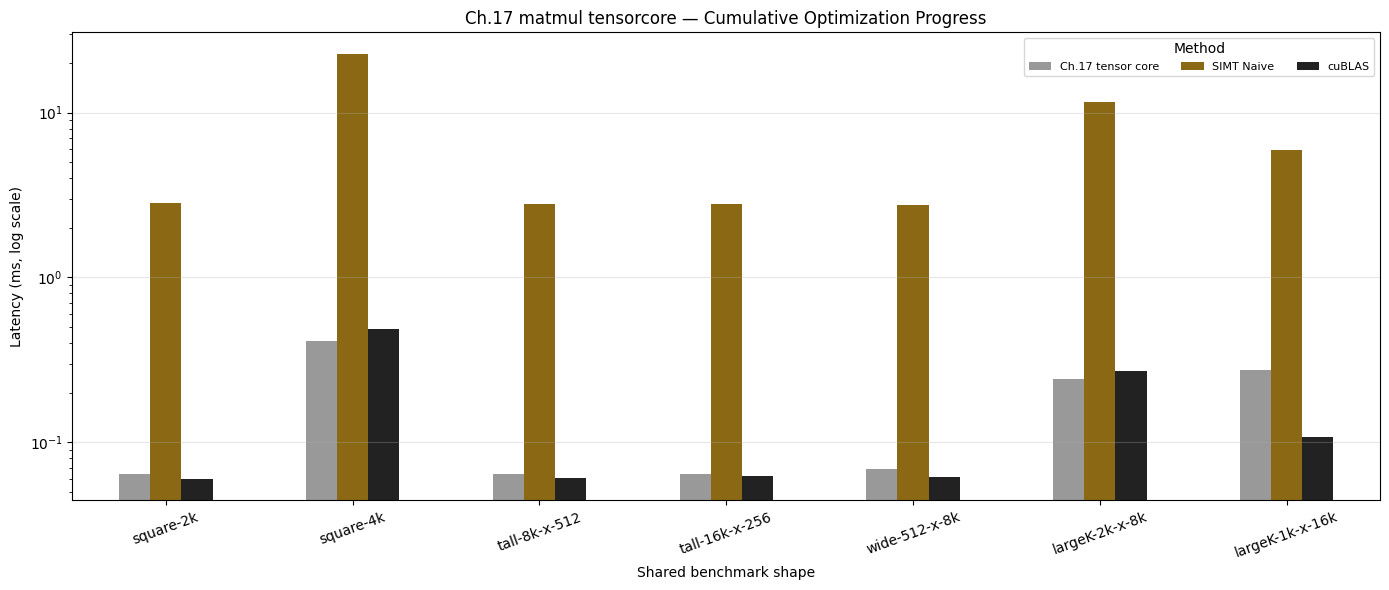

method,Ch.17 tensor core,SIMT Naive,cuBLAS
shape_name,,,
square-2k,0.064080,2.831432,0.059813
square-4k,0.410984,22.808058,0.486918
tall-8k-x-512,0.064613,2.806618,0.060630
tall-16k-x-256,0.064282,2.810155,0.062250
wide-512-x-8k,0.069162,2.753403,0.061997
largeK-2k-x-8k,0.243064,11.669448,0.270525
largeK-1k-x-16k,0.273941,5.931062,0.107235


In [7]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans', 'sans-serif']

plot_methods = ["SIMT Naive", "Ch.17 tensor core", "cuBLAS"]
plot_df = chapter17_df[chapter17_df["method"].isin(plot_methods)].copy()
shape_order = [shape.name for shape in BENCHMARK_SHAPES]
pivot_df = plot_df.pivot(index="shape_name", columns="method", values="latency_ms").reindex(shape_order)

ax = pivot_df.plot(
    kind="bar",
    figsize=(14, 6),
    rot=20,
    logy=True,
    color=["#999999", "#8B6914", "#222222"],
)
ax.set_xlabel("Shared benchmark shape")
ax.set_ylabel("Latency (ms, log scale)")
ax.set_title("Ch.17 matmul tensorcore — Cumulative Optimization Progress")
ax.legend(title="Method", ncol=3, fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

pivot_df


## 17.x 统一 Shape Set 数值表

为了让 Part 3 的所有优化章节可以横向比较，本表使用与 Ch.12、Ch.13、Ch.14、Ch.15、Ch.16 和 Ch.18 相同的 7 个共享矩阵形状。

本章给出 `Ch.17 tensor core` 与 `cuBLAS` 的统一 benchmark，主指标是 `latency_ms`，并附带 `TFLOPS`、相对 `cuBLAS` 的速度比，以及正确性结果。若某个方法运行失败，会保留为 `NaN/False`。

## 17.7 nd vs nz 共享内存布局 — Swizzle 的秘密

### 术语来源

"nd" 和 "nz" 来自 CUTLASS / Triton 编译器内部术语：

- **nd (naive-dense)**：朴素的行主序/列主序存储，地址连续，无变换
- **nz (non-zero swizzle)**：通过 XOR 位运算重映射地址，消除 bank conflict

在 Triton MLIR IR 中对应：
- `SwizzledSharedEncodingAttr`：参数 `vec`, `perPhase`, `maxPhase`, `order`
- `NVMMASharedEncodingAttr`：参数 `swizzlingByteWidth` (0/32/64/128)

### nd 布局 — 直觉上最简单

```
nd 布局: 直接按行存储到 shared memory

A 矩阵块 8×8 (FP16, 2 bytes/elem), 每行 16 bytes = 4 banks

Bank 编号 (32 banks × 4 bytes):
Row 0: [a00 a01] [a02 a03] [a04 a05] [a06 a07]  → bank 0,1,2,3
Row 1: [a10 a11] [a12 a13] [a14 a15] [a16 a17]  → bank 0,1,2,3
Row 2: [a20 a21] [a22 a23] [a24 a25] [a26 a27]  → bank 0,1,2,3
  ...
Row 7: [a70 a71] [a72 a73] [a74 a75] [a76 a77]  → bank 0,1,2,3

问题: 所有行的同一列都落在同一个 bank!
      ldmatrix 读列时 → 多线程争抢同一 bank → 串行化
```

实际场景更典型：`BLOCK_K=16` 时每行 32 bytes = 8 banks，列访问产生 **4-way bank conflict**。
对应 CUDA 代码 `simt_smem.cu` 的性能瓶颈。

### nz 布局 — XOR Swizzle

```
核心公式:
  phase = (row / perPhase) % maxPhase
  swizzled_col_group = col_group ^ phase

示例 (vec=2, perPhase=1, maxPhase=8, 8×16 tile):

原始 nd 列组:     0 1 2 3 4 5 6 7    nz swizzle 后:
Row 0 (phase=0):  0 1 2 3 4 5 6 7    0 1 2 3 4 5 6 7  (^0, 不变)
Row 1 (phase=1):  0 1 2 3 4 5 6 7    1 0 3 2 5 4 7 6  (^1)
Row 2 (phase=2):  0 1 2 3 4 5 6 7    2 3 0 1 6 7 4 5  (^2)
Row 3 (phase=3):  0 1 2 3 4 5 6 7    3 2 1 0 7 6 5 4  (^3)
Row 4 (phase=4):  0 1 2 3 4 5 6 7    4 5 6 7 0 1 2 3  (^4)
Row 5 (phase=5):  0 1 2 3 4 5 6 7    5 4 7 6 1 0 3 2  (^5)
Row 6 (phase=6):  0 1 2 3 4 5 6 7    6 7 4 5 2 3 0 1  (^6)
Row 7 (phase=7):  0 1 2 3 4 5 6 7    7 6 5 4 3 2 1 0  (^7)

数字 = 该元素组存放的 bank group 编号
关键: 每列方向上, 相邻行映射到不同 bank → 无 conflict!
```

XOR 的精妙之处：`col ^ row` 保证了**同列不同行**的数据落在不同 bank，而**同行内**的数据仍然连续（行内访问无影响）。

### 为什么偏偏选 XOR（Z 字形），而不是其他排列？

这是 swizzle 设计中最关键的问题。消除 bank conflict 的方案不止一种，为什么 XOR 胜出？

**方案对比：三种消除 bank conflict 的思路**

```
方案 1: 行偏移 (Shift)
  Row 0: bank 0,1,2,3,4,5,6,7
  Row 1: bank 1,2,3,4,5,6,7,0   (shift +1)
  Row 2: bank 2,3,4,5,6,7,0,1   (shift +2)
  ...
  公式: new_col = (col + row) % num_banks

  ✓ 消除列方向 bank conflict
  ✗ 同行内连续性被破坏! 行尾 wrap 到行首, 地址不连续
  ✗ 取模运算在硬件上代价高 (需要除法器或查表)
  ✗ 行尾元素跨越 bank 边界, 无法向量化加载

方案 2: 查找表 (LUT)
  预先算好每个 (row, col) 对应的 bank 映射表

  ✓ 可以构造出任何完美的排列
  ✗ 需要额外的片上存储放查找表
  ✗ 查找延迟 > 1 个周期
  ✗ 不同 tile size 需要不同的表, 无法通用化

方案 3: XOR (选中!)
  Row 0: col ^ 0 = 0,1,2,3,4,5,6,7
  Row 1: col ^ 1 = 1,0,3,2,5,4,7,6
  Row 2: col ^ 2 = 2,3,0,1,6,7,4,5
  ...
  公式: new_col = col ^ row

  ✓ 消除列方向 bank conflict (数学上可证明)
  ✓ 同行内元素仍然"局部连续" (见下方分析)
  ✓ XOR 是单周期位运算, 零延迟
  ✓ 自反性: XOR 两次还原 → 读写用同一公式
  ✓ 通过 vec/perPhase/maxPhase 参数适配任何 tile size
```

**关键 1：XOR 为什么不破坏行内连续性？**

```
行内连续性分析 (Row 1, phase=1):
  原始:  col 0,1,2,3,4,5,6,7
  XOR 1: col 1,0,3,2,5,4,7,6

  看起来被打乱了? 但仔细看:
    [0,1] → [1,0]  两个元素只是在 pair 内交换
    [2,3] → [3,2]  同一个 bank 内的两个元素交换
    [4,5] → [5,4]  ...

  每 2 个连续元素 (1 个 bank = 4 bytes = 2×FP16) 仍在同一个 bank!
  vec=2 就是控制这个: 每 vec 个元素作为一组, 组内地址不变!

  XOR 只在 "bank group" 级别做重排, 不拆散 vec 内部的连续性
  → 向量化加载 (float4, 128-bit) 仍然可用!
```

**关键 2：XOR 的自反性（self-inverse）**

```
XOR 的数学性质: a ^ b ^ b = a

写入 smem: addr = base + (col ^ phase)   // 写到 swizzle 后的位置
读取 smem: 已知 swizzle 后的位置, XOR 同一个 phase 即可还原

这意味着:
  - 写入和读取用完全相同的地址计算公式
  - 不需要额外的"逆映射表"
  - 编译器只需要在所有 smem 访问处插入同一个 XOR 运算

对比 shift: (col + row) % N 的逆运算是 (col - row + N) % N
  → 需要减法和条件取模, 不对称, 更复杂
```

**关键 3：XOR 的无冲突性可数学证明**

```
定理: 对于 N = 2^k 个 bank, XOR swizzle 保证任意 N 行中
      同一列的 N 个元素落在 N 个不同 bank 上。

证明 (简要):
  Row i 的第 c 列落在 bank: b_i = c ^ i
  Row j 的第 c 列落在 bank: b_j = c ^ j
  
  若 i ≠ j, 则 b_i ^ b_j = (c ^ i) ^ (c ^ j) = i ^ j ≠ 0
  → b_i ≠ b_j  (两个不同行的同列元素必在不同 bank)  ∎

关键前提: bank 数量 N = 2^k, 而 XOR 恰好在 GF(2^k) 上构成群
  → 这就是为什么 GPU 有 32 = 2^5 个 bank!
  → 硬件设计和 swizzle 算法是协同优化的
```

**总结：XOR 胜出的五个原因**

```
1. 零硬件成本 — XOR 是最简单的位运算, 1 个周期, 0 面积
2. 保持局部连续 — vec 内元素不动, 向量化加载不受影响
3. 自反性 — 同一公式用于读和写, 编译器实现极简
4. 数学完美 — 在 2^k 大小上保证零冲突 (群论性质)
5. 参数化通用 — vec/perPhase/maxPhase 适配所有 tile 配置

说白了, XOR swizzle 不是"碰巧好用", 而是 2 的幂次 bank 结构
下数学上唯一的最优位运算排列。Shift 能消除冲突但破坏连续性,
LUT 灵活但代价太高, 只有 XOR 同时满足所有约束。
```

### ldmatrix 与 nz 布局的配合

`ldmatrix.sync.aligned.m8n8.x2.b16` 是 warp 级指令，每个线程提供一个 smem 地址，硬件一次性搬运 8×8 tile 到 mma 寄存器。

```
ldmatrix 的访问模式:
  Thread 0 → 读 smem[row0][col0:col7]  (连续 16 bytes, 一整行)
  Thread 1 → 读 smem[row1][col0:col7]
  ...
  Thread 7 → 读 smem[row7][col0:col7]

nd 布局下:
  Thread 0 读 row 0 → banks {0,1,2,3}
  Thread 1 读 row 1 → banks {0,1,2,3}  ← 同一组 bank!
  Thread 2 读 row 2 → banks {0,1,2,3}  ← 同一组 bank!
  → 4-way (或更多) bank conflict!

nz 布局下:
  Thread 0 读 row 0 → banks {0,1,2,3}   (phase=0)
  Thread 1 读 row 1 → banks {1,0,3,2}   (phase=1, swizzled)
  Thread 2 读 row 2 → banks {2,3,0,1}   (phase=2)
  Thread 3 读 row 3 → banks {3,2,1,0}   (phase=3)
  → 每个线程访问不同 bank → 零 conflict!
```

### ldmatrix → mma.sync 的零开销数据通路

```
关键: ldmatrix 的输出寄存器布局 = mma.sync 的输入布局

不用 ldmatrix (手动加载):
  1. smem → 临时寄存器 (有 bank conflict)
  2. 手动重排到 mma 期望的布局  ← 额外指令开销!
  3. mma.sync 执行

用 ldmatrix + nz:
  1. ldmatrix 从 swizzled smem 加载  ← 零 bank conflict
  2. 输出已是 mma 期望的布局        ← 零重排开销!
  3. mma.sync 执行

完整数据流:
Global Mem → cp.async → Shared Mem (nz) → ldmatrix → Registers → mma.sync → Registers
                          ↑ swizzle          ↑ 零 conflict    ↑ 零重排     ↑ Tensor Core
```

对应 CUDA 代码：
- `mma_naive.cu`：无 smem，直接全局内存 → mma（最慢）
- `mma_smem.cu`：nd smem + 手动加载 → mma
- `mma_ldmatrix.cu`：nz smem + ldmatrix → mma（快 ~15%）
- `mma_pipeline.cu`：nz smem + ldmatrix + 流水线 → mma（最快）

### 为什么 nz 能加速？三个层面

```
层面 1: 消除 Bank Conflict
  nd: 4~8-way conflict → 每次读 4~8 个周期
  nz: 0 conflict       → 每次读 1 个周期
  smem 带宽利用率: ~12-25% → ~100%

层面 2: 启用 ldmatrix 硬件加速
  nd + 手动加载: ~4-6 条指令/元素
  nz + ldmatrix: 1 条指令加载整个 8×8 tile
  指令数减少 4-6×

层面 3: 流水线效率提升
  nd: smem 读取慢 → 计算单元等待 → 流水线气泡
  nz: smem 读取快 → 计算/访存完美重叠 → 利用率高
```

### Triton 中的自动化

开发者只需要写：

```python
a_block_ptr = tl.make_block_ptr(
    ..., block_shape=(BLOCK_M, BLOCK_K), order=(1, 0),  # 行主序
)
a_tile = tl.load(a_block_ptr, boundary_check=(0, 1))
acc = tl.dot(a_tile, b_tile, acc=acc)   # 触发 Tensor Core 路径
```

编译器看到 `order=(1,0)` + `tl.dot` 后自动完成：
1. 选择最优 swizzle 参数 (vec, perPhase, maxPhase)
2. `cp.async` 按 swizzle 布局写入 smem
3. `ldmatrix` 零 conflict 加载到 mma 寄存器
4. `mma.sync` 执行 Tensor Core 矩阵乘

在 TTGIR 中可以看到编译器的选择：

```
// 通用 swizzle (MMAv1/v2):
#shared = #triton_gpu.shared<{vec=8, perPhase=1, maxPhase=8, order=[1,0]}>

// Hopper MMAv3 专用:
#shared = #triton_nvidia_gpu.shared<{swizzlingByteWidth=128}>
```

### nd vs nz 对比总结

| 维度 | nd (朴素) | nz (swizzle) |
|------|----------|-------------|
| 地址计算 | `row * stride + col` | `row * stride + (col ^ phase)` |
| Bank conflict | 严重 (4-8 way) | 零 |
| ldmatrix | 有 conflict，需手动加载 | 完美匹配，零 conflict |
| mma 寄存器 | 需手动重排 | ldmatrix 直接输出正确布局 |
| smem 带宽 | ~12-25% | ~100% |
| CUDA 实现 | 简单 | 地址计算复杂 (~50行) |
| Triton 中 | 不会使用 | 编译器自动 (1 个 order 参数) |

## 17.8 总结

### 本章要点

1. **Tensor Core 硬件**：GPU 中的专用矩阵乘法单元，一条指令完成小矩阵乘法
   - WMMA: 16x16x16, MMA: 16x8x8 等
   - Warp 级别操作 (32 线程协作)

2. **三种编程方式**：
   | 方式 | 代码量 | 灵活性 | 性能 |
   |------|--------|--------|------|
   | WMMA API | ~50行 | 中 | 中 |
   | MMA PTX | ~200行 | 最高 | 最高 |
   | Triton tl.dot | ~5行 | 中高 | 接近最高 |

3. **tl.dot 的工作原理**：
   - 编译器根据 block shape 和 GPU 架构选择最优的 MMA 指令
   - 自动处理数据布局、对齐、寄存器分配
   - 自动使用 ldmatrix 高效加载

4. **Block Size 要求**：
   - BLOCK_M, BLOCK_N: 必须是 16 的倍数
   - BLOCK_K: 必须是 16 的倍数
   - 更大的 block → 更好的数据复用，但受 smem 限制

5. **nd vs nz 共享内存布局**：
   - nd (naive-dense): 朴素布局，存在严重 bank conflict
   - nz (non-zero swizzle): XOR 重映射消除 conflict，匹配 ldmatrix 访问模式
   - ldmatrix 输出直接匹配 mma.sync 输入 → 零重排开销
   - Triton 通过 `order` 参数 + 编译器自动选择最优 swizzle

6. **100 行 CUDA = 1 行 Triton**：
   - 100+ 行的 CUDA MMA 代码 (寄存器声明 + 地址计算 + asm + 存储) 在 Triton 中只需 1 行 `tl.dot`
   - ~50 行的 CUDA swizzle 地址计算在 Triton 中只需 1 个 `order=(1,0)` 参数
   - 编译器承担了所有底层复杂性

### 练习

1. **PTX 查看**：使用 `kernel.warmup(...)` 后查看 PTX，找到 `mma.sync` 和 `ldmatrix` 指令
2. **非16对齐**：尝试 BLOCK_M=96, BLOCK_N=96，观察编译器行为
3. **性能分析**：使用 NCU profiler 查看 Tensor Core 利用率和 bank conflict 计数
4. **思考题**：在 Blackwell 上 WMMA naive (0.2952ms) 比 MMA naive (0.3138ms) 更快，为什么？
   （提示：WMMA 的内部实现可能自动做了 nz swizzle 优化）
5. **Swizzle 验证**：用 Python 模拟 XOR swizzle 公式，验证 8 行内不同行同列不会落在同一 bank

### 下一章预告

第18章将是 **终极优化 GEMM** —— 组合所有技巧 (block_ptr, swizzle, pipeline, precision, autotuning)，
实现一个接近 cuBLAS 性能的完整 GEMM kernel。